In [5]:
import sys, importlib, os
repo_start = f'../'
sys.path.append(repo_start)

from modules.utils.imports import *
from modules.utils.numpy_torch_conversion import *
from modules.binn_eql.build_binn_eql_net import BINN
from modules.loaders.format_data import format_data_general
from modules.generate_data.simulate_system import *
from modules.binn.model_wrapper import model_wrapper
import modules.generate_data.simulate_system

In [6]:
dir_name = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/debugging/27_pruning_20k_sweep/binn_eql_gls_1_pde_1_l05_0.001_repeat_5'

In [8]:
# load params from configuration file
config = {}
exec(Path(f'{dir_name}/config.cfg').read_text(encoding="utf8"), {}, config)

# Training data params
training_data_path = config['training_data_path']
species = int(config['species'])
dimensions = int(config['dimensions'])
epsilon = float(config['epsilon'])
points = int(config['points'])

# BINN params
diff_coeffs = [float(x) for x in config['diff_coeffs'].strip("()").split()]

# Symbolic Net params
duplicates = int(config['duplicates'])
degree = int(config['degree'])
gls_weight=float(config['gls_weight'])
pde_weight=float(config['pde_weight'])
l05_weight = float(config['l05_weight'])
param_bounds = float(config['param_bounds'])

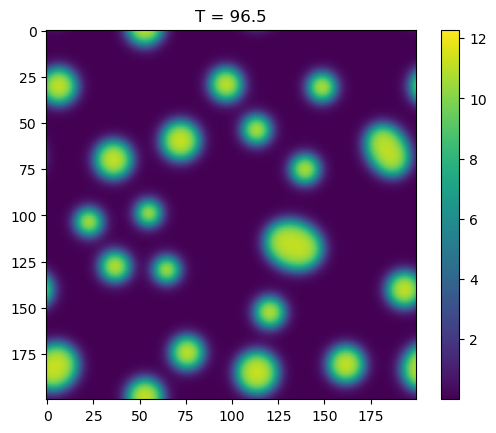

In [9]:
# Set training hyperparameters
epochs = int(1e6)
# epochs = 1000
rel_save_thresh = 0.01

# Get GPU
device = 'cpu'

# Load training data (columns: x*dimensions, t, species concentrations)
training_data = format_data_general(dimensions, species, file=training_data_path)

# Add noise to training data if specified in config file
if epsilon != 0 or points != 0:
    training_data = noise_and_interpolate(training_data, points, epsilon, dimensions, species)

animate_data(training_data, dimensions, species, name=f'{dir_name}/training_data')

# Create triangle mesh from min and max uv vals seen in training data
u_triangle_mesh, v_triangle_mesh = lltriangle(training_data[:, -2:], 
                                                training_data[:, -1:])
# Create 1d arrays from meshes
u_triangle, v_triangle = np.ravel(u_triangle_mesh), np.ravel(v_triangle_mesh)

# Create separate variables for arrays containing and not containing nans
uv_nans = np.stack((u_triangle, v_triangle), axis=1)
mask = ~np.isnan(uv_nans).any(axis=1)
uv = torch.from_numpy(uv_nans[mask]).to(device)

# Generate true surface
params = 1, 1, 0.01
F_true = wave_pinning(uv_nans, params).reshape(501, 501)

In [5]:
def visualize_surface(model, dimensions, species, reaction, params, model_dir, training_data_path):
    
    # Load and format training data
    training_data = format_data_general(dimensions, species, training_data_path)
    u = training_data[:, dimensions+1]
    v = training_data[:, dimensions+2]
    u_triangle_mesh, v_triangle_mesh = lltriangle(u, v)

    # u_points = np.linspace(np.min(u), np.max(u), 501)
    # v_points = np.linspace(np.min(v), np.max(v), 501)

    # u_triangle_mesh, v_triangle_mesh = np.meshgrid(u_points, v_points)

    # Calculate true reaction surface
    F_true = reaction(u_triangle_mesh, v_triangle_mesh, params[2:])

    # Calculate MLP reaction surface
    uv = np.column_stack((np.ravel(u_triangle_mesh), np.ravel(v_triangle_mesh)))
    F_mlp_stacked = to_numpy(model.model.reaction(to_torch(uv)[:, None]))
    F_mlp = np.reshape(F_mlp_stacked, (501, 501))

    # Plot
    fig = make_subplots(rows=1, cols=2,
                        specs=[[{'type':'scene'}, {'type':'scene'}]],
                        subplot_titles=('F(u, v)', 'F*(u, v)'),
                        horizontal_spacing = 0)

    fig.layout.annotations[0].update(y=0.8)
    fig.layout.annotations[1].update(y=0.8)
    fig.update_annotations(font_size=24, font_color='#000000')

    fig.add_trace(
        go.Surface(z=F_true, x=u_triangle_mesh, y=v_triangle_mesh,
                                    colorscale='mint',
                                    showscale=False,
                                    colorbar=dict(
                                        x=1.15,
                                        title='True',
                                        len=0.5)),
        row=1, col=1)
    fig.add_trace(
        go.Surface(z=F_mlp, x=u_triangle_mesh, y=v_triangle_mesh,
                                    colorscale='mint',
                                    showscale=False,
                                    colorbar=dict(
                                        title='MLP',
                                        len=0.5)),
        row=1, col=2)

    fig.update_layout(autosize=True,
        width=1500, 
        height=800,
        font=dict(color = '#000000',
                size=20),
        
        scene=dict( 
        xaxis_title='[u] (uM)',
        yaxis_title='[v] (uM)',
        zaxis_title='F',
        xaxis = dict(
            tick0 = 0,
            dtick = 2,
            tickfont = dict(size=18)),
        yaxis = dict(
            tick0 = 0.2,
            dtick = 0.4,
            tickfont = dict(size=18)),
        zaxis = dict(
            tick0 = 0,
            dtick = 2,
            tickfont = dict(size=18),
            range=[-4, 11]),

        camera=dict(eye=dict(x=1, y=-2.5, z=1)),),
                    
        scene2=dict(
        xaxis_title='[u] (uM)',
        yaxis_title='[v] (uM)',
        zaxis_title='F*',
        xaxis = dict(
            tick0 = 0,
            dtick = 2,
            tickfont = dict(size=18)),
        yaxis = dict(
            tick0 = 0.2,
            dtick = 0.4,
            tickfont = dict(size=18)),
        zaxis = dict(
            tick0 = 0,
            dtick = 2,
            tickfont = dict(size=18),
            range=[-4, 11]),

        camera=dict(eye=dict(x=1, y=-2.5, z=1))))

    fig.update_coloraxes(showscale=False)

    fig.show()
    # fig.write_image(f'{model_dir}/f_mlp_surface.png')

In [ ]:
visualize_surface(model, dimensions, species, reaction, params, dir_name, training_data_path)